<a href="https://colab.research.google.com/github/gitirom/5G-Energy-Consumption-Modelling-/blob/Rom_branch/5G_Energy_Concumption_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:


bs_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/BSinfo.csv",)
cl_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/CLdata.csv", parse_dates=['Time'])
ec_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/ECdata.csv", parse_dates=['Time'])

In [4]:
bs_data

,BS,CellName,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,B_0,Cell0,Type1,Mode2,365.000,20,4,6.875934
1,B_1,Cell0,Type2,Mode2,532.000,20,4,6.875934
2,B_2,Cell0,Type1,Mode2,365.000,20,4,6.875934
3,B_3,Cell0,Type2,Mode2,532.000,20,4,6.875934
4,B_4,Cell0,Type2,Mode2,532.000,20,4,6.875934
...,...,...,...,...,...,...,...,...
1212,B_925,Cell1,Type8,Mode1,697.002,10,4,7.877728
1213,B_105,Cell2,Type1,Mode2,426.980,2,2,6.877429
1214,B_745,Cell2,Type1,Mode2,426.980,2,2,6.877429
1215,B_105,Cell3,Type1,Mode2,426.980,2,2,6.877429


In [5]:
cl_data

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-02 19:00:00,B_745,Cell3,0.071000,0.0,0.0,0.0,0,0.0,0.0
125571,2023-01-02 20:00:00,B_745,Cell3,0.064962,0.0,0.0,0.0,0,0.0,0.0
125572,2023-01-02 21:00:00,B_745,Cell3,0.081865,0.0,0.0,0.0,0,0.0,0.0
125573,2023-01-02 22:00:00,B_745,Cell3,0.097615,0.0,0.0,0.0,0,0.0,0.0


In [6]:
ec_data

,Time,BS,Energy
0,2023-01-01 01:00:00,B_0,64.275037
1,2023-01-01 02:00:00,B_0,55.904335
2,2023-01-01 03:00:00,B_0,57.698057
3,2023-01-01 04:00:00,B_0,55.156951
4,2023-01-01 05:00:00,B_0,56.053812
...,...,...,...
92624,2023-01-02 17:00:00,B_1018,14.648729
92625,2023-01-02 18:00:00,B_1018,14.648729
92626,2023-01-02 21:00:00,B_1018,13.452915
92627,2023-01-02 22:00:00,B_1018,13.602392


In [7]:
#mereg bs and cl

df_merged = cl_data.merge(
    bs_data,
    on=['BS', 'CellName'],
    how='outer'  #keeps all rows from both DataFrames, filling missing values with NaN if there’s no match. outer never drops any row, it just aligns them by your on columns and fills missing values with NaN.
)

In [8]:
df_merged

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-02 19:00:00,B_999,Cell0,0.077442,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125571,2023-01-02 20:00:00,B_999,Cell0,0.062808,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125572,2023-01-02 21:00:00,B_999,Cell0,0.062231,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125573,2023-01-02 22:00:00,B_999,Cell0,0.052212,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934


In [9]:
total_df = df_merged.merge(
    ec_data,
    on=['Time', 'BS'],
    how='outer'
)

In [10]:
total_df

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [11]:
total_df_Copy = total_df.copy()
total_df_Copy

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [12]:
total_df.duplicated().sum()

np.int64(0)

In [13]:
total_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125575 entries, 0 to 125574
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Time       125575 non-null  datetime64[ns]
 1   BS         125575 non-null  object        
 2   CellName   125575 non-null  object        
 3   load       125575 non-null  float64       
 4   ESMode1    125575 non-null  float64       
 5   ESMode2    125575 non-null  float64       
 6   ESMode3    125575 non-null  float64       
 7   ESMode4    125575 non-null  int64         
 8   ESMode5    125575 non-null  float64       
 9   ESMode6    125575 non-null  float64       
 10  RUType     125575 non-null  object        
 11  Mode       125575 non-null  object        
 12  Frequency  125575 non-null  float64       
 13  Bandwidth  125575 non-null  int64         
 14  Antennas   125575 non-null  int64         
 15  TXpower    125575 non-null  float64       
 16  Energy     98084 non

In [14]:
total_df.describe()

,Time,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,Frequency,Bandwidth,Antennas,TXpower,Energy
count,125575,125575.000000,125575.000000,125575.000000,125575.000000,125575.0,125575.000000,125575.000000,125575.000000,125575.000000,125575.000000,125575.000000,98084.000000
mean,2023-01-03 22:42:31.291260160,0.239009,0.040127,0.036722,0.000085,0.0,0.000011,0.038771,373.535404,15.779144,2.478009,6.744941,28.986888
min,2023-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,155.600000,2.000000,1.000000,5.381166,0.747384
25%,2023-01-02 09:00:00,0.055080,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,189.000000,10.000000,2.000000,6.427504,18.535127
50%,2023-01-03 17:00:00,0.153410,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,365.000000,20.000000,2.000000,6.875934,24.962631
75%,2023-01-05 12:00:00,0.352220,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,532.000000,20.000000,2.000000,6.875934,37.668161
max,2023-01-08 00:00:00,0.993957,1.000000,1.000000,0.154563,0.0,0.768070,0.931032,979.998000,20.000000,64.000000,8.375336,100.000000
std,NaN,0.235750,0.189631,0.182238,0.002437,0.0,0.002803,0.164538,143.393762,5.762653,4.494594,0.340660,14.345648


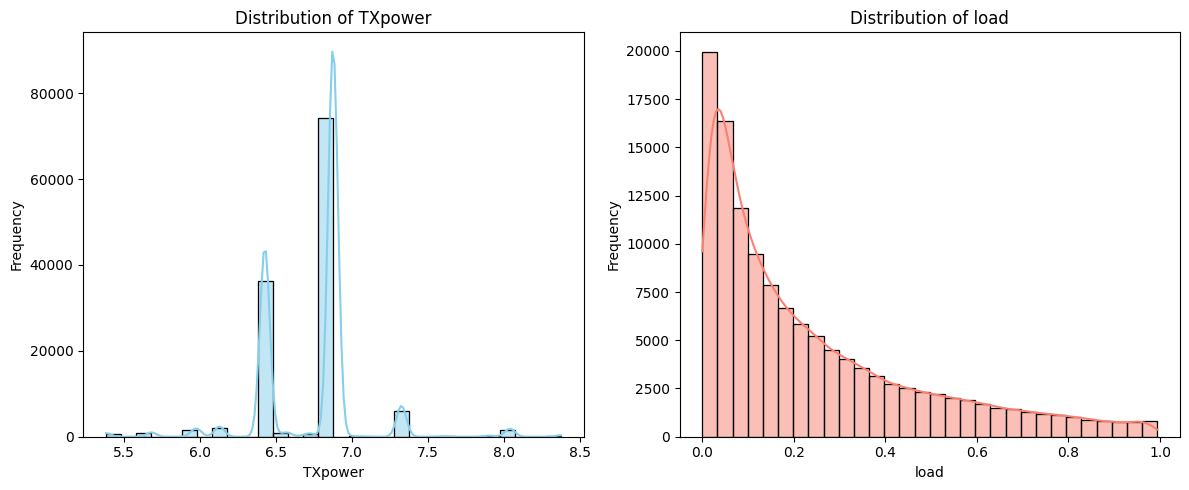

In [15]:


plt.figure(figsize=(12, 5))

# TXpower distribution
plt.subplot(1, 2, 1)  # 1 row, 2 cols, first plot
sns.histplot(total_df['TXpower'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of TXpower")
plt.xlabel('TXpower')
plt.ylabel('Frequency')

# load distribution
plt.subplot(1, 2, 2)
sns.histplot(total_df['load'], bins=30, kde=True, color='salmon')
plt.title("Distribution of load")
plt.xlabel('load')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


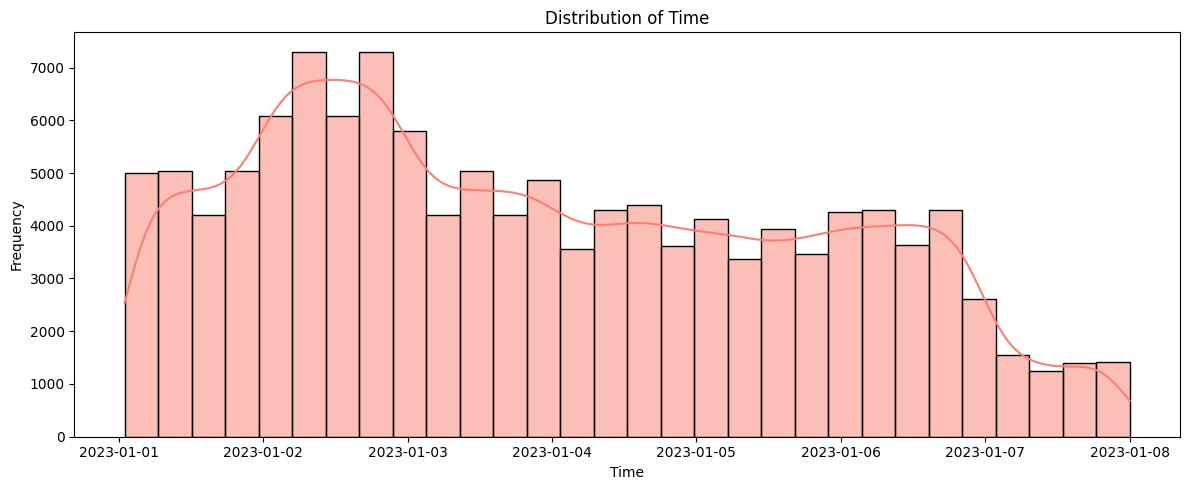

In [16]:


plt.figure(figsize=(12, 5))

sns.histplot(total_df['Time'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Time")
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


The distribution **shows a higher concentration of events between January 2nd and 3rd, followed by a gradual decrease towards January 7th–8th**. This suggests temporal clustering of activity earlier in the observed period, potentially influenced by operational or behavioral factors.

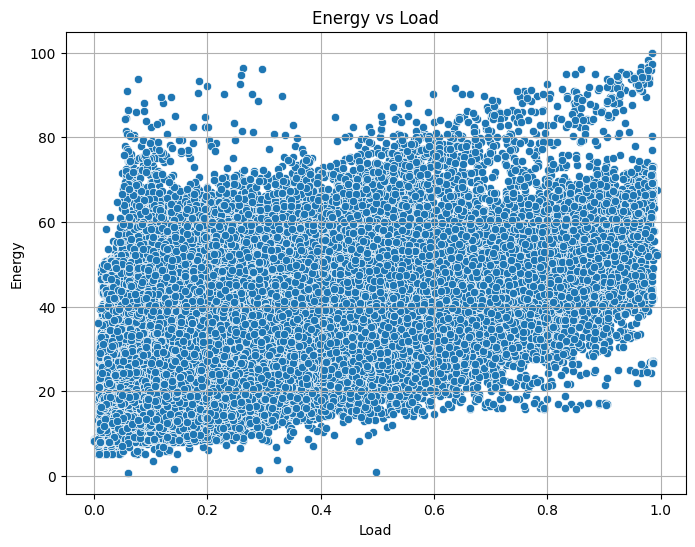

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="load", y='Energy', data=total_df)
plt.title('Energy vs Load')
plt.xlabel('Load')
plt.ylabel('Energy')
plt.grid(True)
plt.show()


In [18]:
energy_by_load = total_df.groupby('load')['Energy'].agg(['min', 'max', 'mean', 'count']).reset_index()
print(energy_by_load)

           load        min        max       mean  count
0      0.000000   8.221226   8.669656   8.267615     29
1      0.001226        NaN        NaN        NaN      0
2      0.001338        NaN        NaN        NaN      0
3      0.001782        NaN        NaN        NaN      0
4      0.001797        NaN        NaN        NaN      0
...         ...        ...        ...        ...    ...
70500  0.992266  52.167414  52.167414  52.167414      1
70501  0.992457        NaN        NaN        NaN      0
70502  0.993064  67.563528  67.563528  67.563528      1
70503  0.993628        NaN        NaN        NaN      0
70504  0.993957  52.765321  52.765321  52.765321      1

[70505 rows x 5 columns]


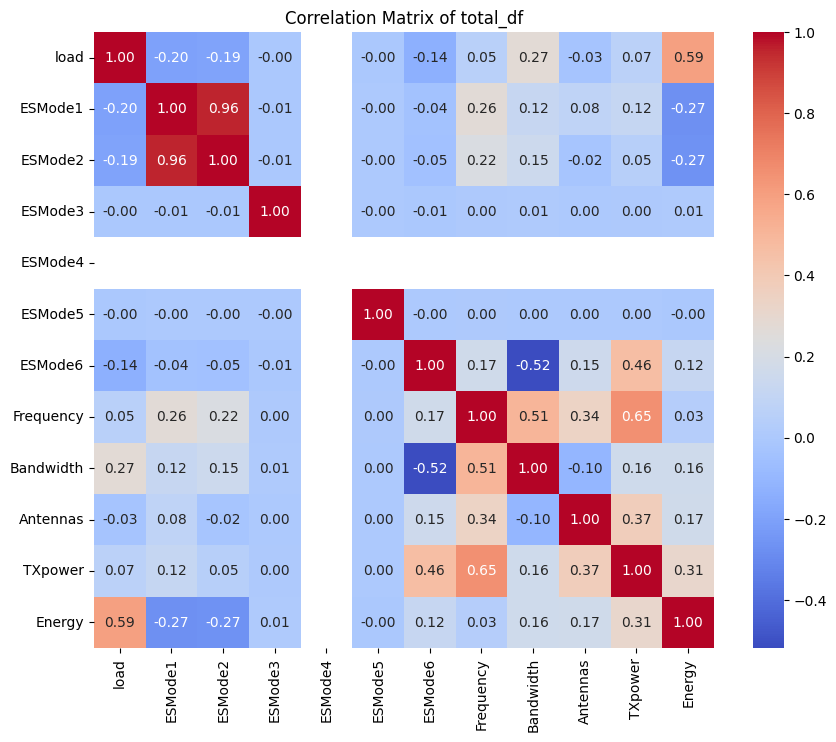

In [19]:
corr_matrix = total_df.select_dtypes('number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of total_df")
plt.show()

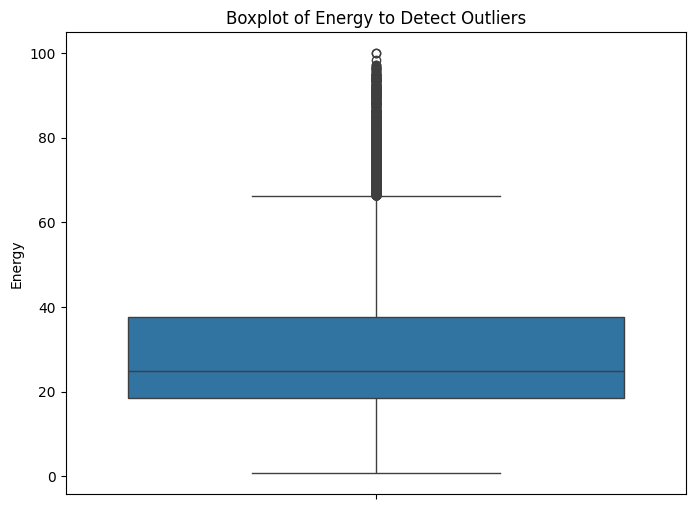

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(y='Energy', data=total_df)
plt.title('Boxplot of Energy to Detect Outliers')
plt.ylabel('Energy')
plt.show()

**load vs Energy** = 0.595 → moderately strong positive correlation.

*Higher load tends to result in higher energy consumption*, which makes sense physically.

**TXpower vs Energy** = 0.309 → weak-to-moderate positive correlation.

*As transmission power increases, energy consumption increases*, but not as strongly as load.

Other variables like Frequency, Bandwidth, Antennas, and ESMode mostly have weak correlations (<0.2) with Energy.

In [21]:
corrl = total_df.select_dtypes("number").corr()
print(corrl)

               load   ESMode1   ESMode2   ESMode3  ESMode4   ESMode5  \
load       1.000000 -0.198885 -0.192635 -0.003070      NaN -0.003700   
ESMode1   -0.198885  1.000000  0.957473 -0.007346      NaN -0.000830   
ESMode2   -0.192635  0.957473  1.000000 -0.006992      NaN -0.000789   
ESMode3   -0.003070 -0.007346 -0.006992  1.000000      NaN -0.000139   
ESMode4         NaN       NaN       NaN       NaN      NaN       NaN   
ESMode5   -0.003700 -0.000830 -0.000789 -0.000139      NaN  1.000000   
ESMode6   -0.135873 -0.043766 -0.047483 -0.008214      NaN -0.000936   
Frequency  0.053004  0.264829  0.222688  0.004435      NaN  0.004391   
Bandwidth  0.272773  0.122045  0.147595  0.013361      NaN  0.002910   
Antennas  -0.028476  0.084058 -0.022781  0.002282      NaN  0.001345   
TXpower    0.067151  0.115592  0.048987  0.004171      NaN  0.001528   
Energy     0.594971 -0.269606 -0.267593  0.013684      NaN -0.004684   

            ESMode6  Frequency  Bandwidth  Antennas   TXpower  

In [36]:
assert total_df['ESMode4'].isna().all()

AssertionError: 

The **assert** will silently pass  

*   **if all values are NaN**
 or raise an
*   **error if NOT all NaN**



In [37]:
print(total_df['ESMode4'].notna().sum())

125575


In [38]:
print(total_df['ESMode4'].value_counts(dropna=False))

ESMode4
0    125575
Name: count, dtype: int64


ESMode4 is **not NaN, it's filled with zeros**. Every single row is 0. This is effectively a **constant column**

Why drop a constant column?

*   Variance = 0 → **model learns nothing from it**



In [39]:
assert (total_df['ESMode4'] == 0).all()

In [41]:
cleaned_df = total_df.drop(columns=['ESMode4'])
print(f"Dropped ESMode4 — was constant (all zeros, {len(total_df)} rows)")
cleaned_df

Dropped ESMode4 — was constant (all zeros, 125575 rows)


,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [43]:
cleaned_df.shape

(125575, 16)

=> **Handle ESMode1/2 redundancy**

In [45]:
print(cleaned_df[['ESMode1', 'ESMode2']].describe())

             ESMode1        ESMode2
count  125575.000000  125575.000000
mean        0.040127       0.036722
std         0.189631       0.182238
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000000       0.000000
max         1.000000       1.000000


In [48]:
# 2. How often are they both active at the same time?
both_active = ((cleaned_df['ESMode1'] == 1) & (cleaned_df['ESMode2'] == 1)).sum()
only1 = ((cleaned_df['ESMode1'] == 1) & (cleaned_df['ESMode2'] == 0)).sum()
only2 = ((cleaned_df['ESMode1'] == 0) & (cleaned_df['ESMode2'] == 1)).sum()
neither = ((cleaned_df['ESMode1'] == 0) & (cleaned_df['ESMode2'] == 0)).sum()


print(f"Both active:  {both_active}")
print(f"Only ESMode1: {only1}")
print(f"Only ESMode2: {only2}")
print(f"Neither:      {neither}")


print(f"\nCorrelation: {cleaned_df['ESMode1'].corr(cleaned_df['ESMode2']):.4f}")


Both active:  1614
Only ESMode1: 278
Only ESMode2: 0
Neither:      118982

Correlation: 0.9575




*   ESMode2 never activates independently (always co-occurs with ESMode1)
*   Correlation = 0.957 — near duplicate. Drop ESMode2, keep ESMode1.


## 📊 Feature Pattern Handling Guide

| Pattern | Best Solution |
|--------|---------------|
| ❌ Never both active at the same time (mutually exclusive) | ➜ Combine them → `ESMode_active = ESMode1 + ESMode2` → values become **{0,1,2}** |
| 🔁 Always identical values | ➜ Drop one feature — **pure duplicate** |
| 📈 High correlation (>0.9) | ➜ Drop one feature — **near duplicate** |
| 🔀 Independent, both active sometimes | ➜ Keep both — **each carries unique information** |
| ⚪ One is almost always 0 | ➜ Drop that feature — **near constant** |

In [49]:
cleaned_df = cleaned_df.drop(columns=['ESMode2'])
cleaned_df

,Time,BS,CellName,load,ESMode1,ESMode3,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


**=> Encode categoricals**

In [44]:
for col in cleaned_df.columns:
  if cleaned_df[col].dtype == 'object':
    print(col)

BS
CellName
RUType
Mode


In [23]:
for col in total_df.columns:
  if total_df[col].dtype == 'object':
    freq = total_df[col].value_counts()
    print(f'{col} frequency are:\n{freq}\n')

BS frequency are:
BS
B_105    330
B_745    326
B_585    286
B_583    286
B_506    286
        ... 
B_963     24
B_964     24
B_965     24
B_966     24
B_967     24
Name: count, Length: 1020, dtype: int64

CellName frequency are:
CellName
Cell0    118768
Cell1      6711
Cell2        48
Cell3        48
Name: count, dtype: int64

RUType frequency are:
RUType
Type4     32096
Type1     31123
Type6     27604
Type7     16087
Type3      6812
Type2      4835
Type5      4162
Type11      864
Type9       648
Type12      528
Type10      504
Type8       312
Name: count, dtype: int64

Mode frequency are:
Mode
Mode2    123367
Mode1      2208
Name: count, dtype: int64



We replace the bs with low freq with other cause in DL, they increase embedding size unnecessarily and can cause overfitting.

In [24]:

# # Step 1: Frequency counts and proportions
# freq = total_df['BS'].value_counts()
# freq_ratio = total_df['BS'].value_counts(normalize=True)

# # Step 2: Embedding dimension (rule of thumb: min(50, num_categories//2))
# num_categories = total_df['BS'].nunique()
# embedding_dim = min(50, num_categories // 2)

# embedding_table = pd.DataFrame({
#     'Category': freq.index,
#     'Count': freq.values,
#     'Proportion': freq_ratio.values,
#     'Embedding_dim': [embedding_dim]*len(freq)  # same embedding size for all categories
# })

# print(embedding_table)

In [25]:
# top_n = 50
# top_BsCategory = freq.head(top_n).index

# total_df['BS'] = total_df['BS'].where(total_df['BS'].isin(top_BsCategory), 'Other')

Keeps important categories separate

Reduces noise from rare categories

Embeddings are smaller and train faster

In [26]:

# freq = total_df['CellName'].value_counts()
# freq_ratio = total_df['CellName'].value_counts(normalize=True)

# num_categories = total_df['CellName'].nunique()
# embedding_dim = min(50, num_categories // 2)

# embedding_table = pd.DataFrame({
#     'Category': freq.index,
#     'Count': freq.values,
#     'Proportion': freq_ratio.values,
#     'Embedding_dim': [embedding_dim]*len(freq)
# })

# print(embedding_table)

In [27]:

# freq = total_df['RUType'].value_counts()
# freq_ratio = total_df['RUType'].value_counts(normalize=True)

# num_categories = total_df['RUType'].nunique()
# embedding_dim = min(50, num_categories // 2)

# embedding_table = pd.DataFrame({
#     'Category': freq.index,
#     'Count': freq.values,
#     'Proportion': freq_ratio.values,
#     'Embedding_dim': [embedding_dim]*len(freq)
# })

# print(embedding_table)

In [28]:
# top_five = 5

# top_RTCategory = freq.head(top_five).index

# total_df['RUType'] = total_df['RUType'].where(total_df['RUType'].isin(top_RTCategory), 'Other')

In [29]:
# total_df['RUType'].value_counts()

In [30]:
# total_df['Time'].dtype

In [31]:
# towers_to_plot = total_df['BS'].value_counts().nlargest(3).index

# plt.figure(figsize=(14,6))

# sns.lineplot(
#     data=total_df[total_df['BS'].isin(towers_to_plot)],
#     x='Time',
#     y='Energy',
#     hue='BS',
#     marker='o'
# )

# plt.title('Energy over Time for Selected Towers')
# plt.xlabel('Time')
# plt.ylabel('Energy')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

**Phase 2: Data Preprocessing & Feature Engineering**

In [32]:
# total_df.isna().sum()

In [33]:
# total_df = total_df.dropna(subset=['Energy'])  #Drop rows where Energy is missing

In [34]:
# total_df.isna().sum()

In [35]:
# total_df.shape